In [18]:
from urllib import request
from os import path
import pandas as pd
import numpy as np

In [19]:
# Download the white wine dataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/"
fn = "winequality-white.csv"
# YOUR CODE HERE
# Download the file if it doesn't exist
if not path.exists(fn):
    data = request.urlopen(url + fn).read()
    with open(fn, 'wb') as fhand:
        fhand.write(data)

# Load the data into a pandas DataFrame
# Note: This dataset uses semicolons as separators
df = pd.read_csv(fn, sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### Problem 1: groupby
Use the Pandas `groupby` function to create a function that takes no arguments and returns the mean citric acid for wines with each quality level as a series indexed by quality.

In [20]:
def quality_mean():
    return df.groupby('quality')['citric acid'].mean()
    # return df.groupby('quality').mean()['citric acid']
quality_mean()

quality
3    0.336000
4    0.304233
5    0.337653
6    0.338025
7    0.325625
8    0.326514
9    0.386000
Name: citric acid, dtype: float64

In [21]:
assert abs(quality_mean()[9] - 0.386) < 1e-8

### Problem 2: Advanced groupby
Create a new eight-row dataframe called `rollup` based on the `df` dataframe, which reports median pH, median cholides, and median citric acid among wines grouped by whether they are more sugary than most wines, more acidic than more wines, and more alcoholic than most wines. It should look like

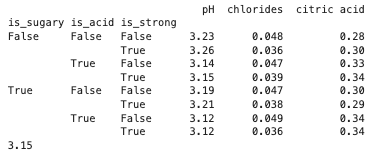

In [23]:
# Calculate medians
median_sugar = df['residual sugar'].median()
median_fixed = df['fixed acidity'].median()
median_alcohol = df['alcohol'].median()

# Create binary indicators
is_sugary = df['residual sugar'] > median_sugar
is_acid = df['fixed acidity'] > median_fixed
is_strong = df['alcohol'] > median_alcohol

# Create rollup with proper grouping and naming
rollup = df.groupby([is_sugary, is_acid, is_strong]).agg({
    'pH': 'median',
    'chlorides': 'median',
    'citric acid': 'median'
})

# Set the index names after creation
rollup.index.names = ['is_sugary', 'is_acid', 'is_strong']

# Print to verify
print("\nFull rollup:")
print(rollup)
print("\nValue at [False][True][True]:", rollup.pH[False][True][True])


Full rollup:
                               pH  chlorides  citric acid
is_sugary is_acid is_strong                              
False     False   False      3.23      0.048         0.28
                  True       3.26      0.036         0.30
          True    False      3.14      0.047         0.33
                  True       3.15      0.039         0.34
True      False   False      3.19      0.047         0.30
                  True       3.21      0.038         0.29
          True    False      3.12      0.049         0.34
                  True       3.12      0.036         0.34

Value at [False][True][True]: 3.15


In [24]:
print(rollup)
print(rollup.pH[False][True][True])
assert abs(rollup.pH[False][True][True] - 3.15) < 1e-8

                               pH  chlorides  citric acid
is_sugary is_acid is_strong                              
False     False   False      3.23      0.048         0.28
                  True       3.26      0.036         0.30
          True    False      3.14      0.047         0.33
                  True       3.15      0.039         0.34
True      False   False      3.19      0.047         0.30
                  True       3.21      0.038         0.29
          True    False      3.12      0.049         0.34
                  True       3.12      0.036         0.34
3.15


## Additional Practice

In [8]:
print("\n----- Group By: reorganizing data -------")
df = pd.DataFrame({'A': ['plant', 'animal', 'plant', 'plant'],
                   'B': ['apple', 'goat', 'kiwi', 'grape'], 
                   'C': np.random.randn(4),
                   'D': np.random.randn(4)})
print(df) 
print(df.groupby('A'))
print(df.groupby('A').groups)
print(df.groupby('A').mean(numeric_only=True))


----- Group By: reorganizing data -------
        A      B         C         D
0   plant  apple  0.176931  0.004494
1  animal   goat  1.492436 -0.260628
2   plant   kiwi  0.562891 -0.297763
3   plant  grape -0.378556  1.167709
{'animal': [1], 'plant': [0, 2, 3]}
               C         D
A                         
animal  1.492436 -0.260628
plant   0.120422  0.291480


In [9]:
# Group By: aggregation
print("\n----- Group by: hierarchically-indexed aggregation -------")
arrs = [['math', 'math', 'eng', 'eng', 'eng', 'sci'],
        ['left', 'right', 'left', 'right', 'left', 'right']]
index = pd.MultiIndex.from_arrays(arrs, names=('major', 'handedness'))
s = pd.Series(np.random.randn(6), index=index)
print(s)
print(s.groupby(level=0).mean()) # group by 'major' level and calculate mean
print(s.groupby('major').get_group('eng')) # examining/pick up groups
print(s.groupby('handedness').mean())
g = s.groupby('handedness'); print(g.aggregate(np.sum)) # aggregate method 


----- Group by: hierarchically-indexed aggregation -------
major  handedness
math   left         -1.477021
       right         0.729879
eng    left         -1.536969
       right         0.966209
       left          0.925278
sci    right         0.724831
dtype: float64
major
eng     0.118173
math   -0.373571
sci     0.724831
dtype: float64
major  handedness
eng    left         -1.536969
       right         0.966209
       left          0.925278
dtype: float64
handedness
left    -0.696237
right    0.806973
dtype: float64
handedness
left    -2.088712
right    2.420918
dtype: float64


C:\Users\Bryant Willoughby\AppData\Local\Temp\ipykernel_25504\2959107206.py:11: FutureWarning: The provided callable <function sum at 0x000001F3AC92FCE0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  g = s.groupby('handedness'); print(g.aggregate(np.sum)) # aggregate method


In [10]:
tsdf = pd.DataFrame(np.random.randn(10, 3), 
                    columns = ['DOW', 'NASDAQ', 'S&P500'],
                    index = pd.date_range('1/1/2000', periods=10))
tsdf.head()

print("\n ----- Aggregating data ------")
print(tsdf.agg(['median', 'mean', 'std'])) # applies to cols of DataFrame
print(tsdf.agg({'DOW': 'mean', 
                'NASDAQ': 'median', 
                'S&P500': 'std'}))


 ----- Aggregating data ------
             DOW    NASDAQ    S&P500
median -0.487092 -0.223595  0.205333
mean   -0.059010  0.093076  0.019884
std     1.271374  1.159217  0.683323
DOW      -0.059010
NASDAQ   -0.223595
S&P500    0.683323
dtype: float64


In [11]:
# Aggregating data for mixed data types 
df = pd.DataFrame({'A': [1,2,3], 
                   'B': [1., 2., 3.], 
                   'C': ['foo', 'bar', 'baz']})
print(df)
print(df.select_dtypes(include='number').agg(['mean', 'max']))

   A    B    C
0  1  1.0  foo
1  2  2.0  bar
2  3  3.0  baz
        A    B
mean  2.0  2.0
max   3.0  3.0


In [12]:
## Statistical and other computations 

print("\n ----- Percent change over time ------")
s = pd.Series(np.random.randn(8)); print(s)
print(s.pct_change())
print(s.pct_change(periods=2))


 ----- Percent change over time ------
0    0.188326
1    0.200521
2   -0.230659
3   -0.115366
4    0.739907
5   -0.755290
6   -0.141733
7    1.149630
dtype: float64
0         NaN
1    0.064755
2   -2.150299
3   -0.499842
4   -7.413555
5   -2.020791
6   -0.812347
7   -9.111253
dtype: float64
0         NaN
1         NaN
2   -2.224786
3   -1.575331
4   -4.207791
5    5.546900
6   -1.191555
7   -2.522103
dtype: float64


In [13]:
print("\n ----- Computing covariances -----")
s1 = pd.Series(np.random.randn(1000)); print(s1)
s2 = pd.Series(0.1*s1+np.random.randn(1000)); print(s2)
s1.cov(s2)


 ----- Computing covariances -----
0      2.089840
1      0.355050
2      1.182209
3     -1.502619
4      0.098584
         ...   
995   -0.946620
996    0.083471
997   -0.216640
998   -0.151157
999    0.388046
Length: 1000, dtype: float64
0      0.140729
1     -1.347249
2     -0.762820
3      0.565255
4      1.000794
         ...   
995    0.770204
996    0.544247
997    0.659894
998   -0.075978
999   -3.094846
Length: 1000, dtype: float64


np.float64(0.13540715373028847)

In [14]:
print("\n----- Ranking method -----")
s = pd.Series(np.random.randn(5), 
              index = list('abcde'))
print(s)
print(s.rank())

# iterating over Series and DataFrames 

print("\n ------ Filtering data ------ ")
sf = pd.Series([1, 1, 2, 2, 3, 3]); print(sf)
print(sf.groupby(sf).filter(lambda x: x.sum() > 2))


----- Ranking method -----
a   -1.752943
b   -0.811656
c    0.140666
d    0.743074
e    1.466103
dtype: float64
a    1.0
b    2.0
c    3.0
d    4.0
e    5.0
dtype: float64

 ------ Filtering data ------ 
0    1
1    1
2    2
3    2
4    3
5    3
dtype: int64
2    2
3    2
4    3
5    3
dtype: int64


In [15]:
print("\n------ Combining DataFrames ------ ")
df1 = pd.DataFrame({'A': np.random.randn(4), 
                    'B': np.random.randn(4), 
                    'C': np.random.randn(4)}, 
                    index = [0, 1, 2, 3])
df2 = pd.DataFrame({'A': np.random.randn(4), 
                    'B': np.random.randn(4)},
                     index = [3, 4, 5, 6])
print(pd.concat([df1, df2]))


------ Combining DataFrames ------ 
          A         B         C
0  0.312162 -0.643381 -0.107732
1 -0.069561  0.099918 -0.055888
2  2.059798 -0.345719 -1.131035
3 -1.259969  0.502124  0.131200
3  0.651859 -1.293451       NaN
4  0.299916  0.492346       NaN
5  1.380571 -0.627221       NaN
6 -0.411157  1.159076       NaN


In [16]:
## Stacking and pivoting 

# use pivot to unstack 
# df.pivot(index = 'date', 
#          columns = 'variable', 
#          values = 'value')

# the reverse process

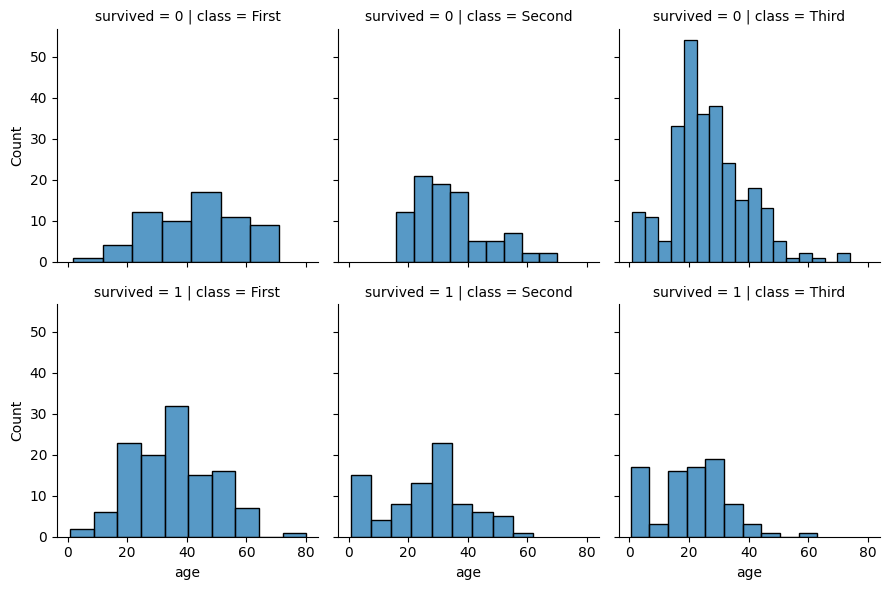

In [17]:
## Visualize: One Seaborn example 
import seaborn as sns 

titanic = sns.load_dataset('titanic')
grid = sns.FacetGrid(titanic, row = 'survived', col='class')
_ = grid.map(sns.histplot, "age")
